# 소매점의 주간 평균 유동인구 예측

- 매장 관리자가 직원의 스케줄을 더 잘 관리할 수 있도록 소매점의 주간 평균 유동인구를 예측하고자 한다고 가정
    - 예상 유동인구에 따라 직원 수를 조절하면 급여 지출을 최적화하면서도 업무 과부하가 없도록 할 수 있음

In [1]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("./data/foot_traffic.csv")
df.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


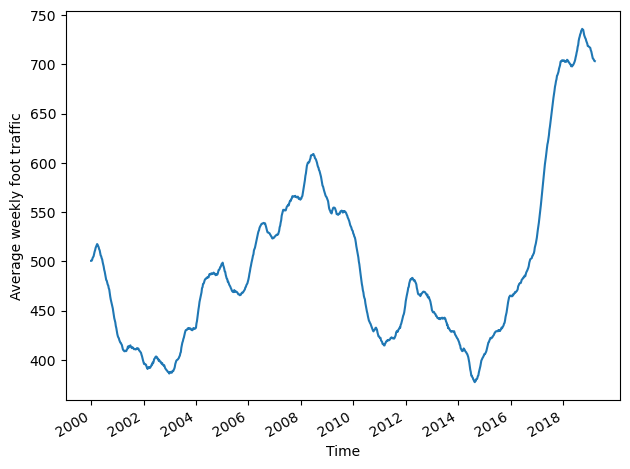

In [3]:
fig, ax = plt.subplots()

ax.plot(df["foot_traffic"])
ax.set_xlabel("Time")
ax.set_ylabel("Average weekly foot traffic")

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 최고점과 최저점이 있는 장기적인 추세를 확인할 수 있음

- 시간에 따른 추세가 있으므로 정상적 프로세스는 아님
    - 가장 최근 추세인 2016년 이후는 증가 추세
 
- 또한 데이터에 뚜렷한 주기적 패턴이 관측되지 않음

- 주간 평균 유동인구를 예측하려면 기반 프로세스를 파악해야함

# 자기회귀프로세스 정의

- 자기회귀프로세스는 예측값이 이전 값에만 선형적으로 의존한다고 가정
    - 즉 변수가 자기 자신에게 회귀하는 것
 
- 자기회귀 프로세스(autoregressive process)는 AR(p) 프로세스로 표시하고, p는 차수임
    - $$y_t = C + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \epsilon_t$$
        - $y_t$ : 현재값
        - $C$ : 상수
        - $\epsilon_p$ : 현재 오차 항(백색소음)
        - $\phi_p$ : 과거의 값이 현재값에 미치는 영향의 크기
            - AR(p) 모델의 계수
         
- 차수 p는 현재값에 영향을 미치는 과거값들의 개수
    - 예) AR(1), 즉 1차 자기회귀 프로세스의 경우 현재값은 상수, 이전 timestep의 값, 일부 백색소음에 의존함

- $\phi_1 = 1$ 일 경우, 수식은 $y_t = C + y_{t-1} + \epsilon_t$ 가 되는데 이는 확률보행 수식임
    - 따라서 확률보행은 차수 p가 1이고, $\phi_1$ 은 1인 자기회귀 프로세스의 특수한 경우라고 할 수 있음
    - 또한 C가 0이 아닌 경우에는 표류가 있는 확률보행임

- 이동평균 프로세스와 마찬가지로, 적절한 모델을 구축하려면 자기회귀 프로세스의 정확한 차수를 찾아야 함
    - 예) AR(3) 프로세스로 식별했다면 3차 자기회귀 모델 사용하여 예측 수행

# 정상적 자기회귀 프로세스의 차수 찾기

<img src = "./image/ar차수_식별.png" height = 700 width = 700>

In [4]:
# 정상성 테스트
ADF_result = adfuller(df["foot_traffic"])

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -1.1758885999240765
p-value: 0.6838808917896182


- p-값이 0.05보다 크므로 귀무가설을 기각할 수 없고, 수열은 정상성을 만족하지 않음

In [5]:
# 수열의 평균을 안정화하기 위해 차분
foot_traffic_diff = np.diff(df["foot_traffic"], n = 1)

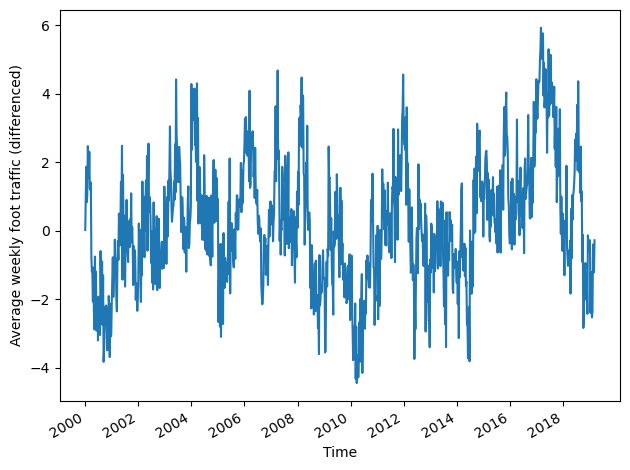

In [6]:
# 차분 데이터 시각화
fig, ax = plt.subplots()

ax.plot(foot_traffic_diff)
ax.set_xlabel("Time")
ax.set_ylabel("Average weekly foot traffic (differenced)")

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [7]:
ADF_result = adfuller(foot_traffic_diff)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -5.26823134742203
p-value: 6.369317654781714e-06


- 차분 이후 p-값이 0.05보다 작아져 귀무가설을 기각할 수 있으므로, 시계열이 정상성을 만족하게 되었음

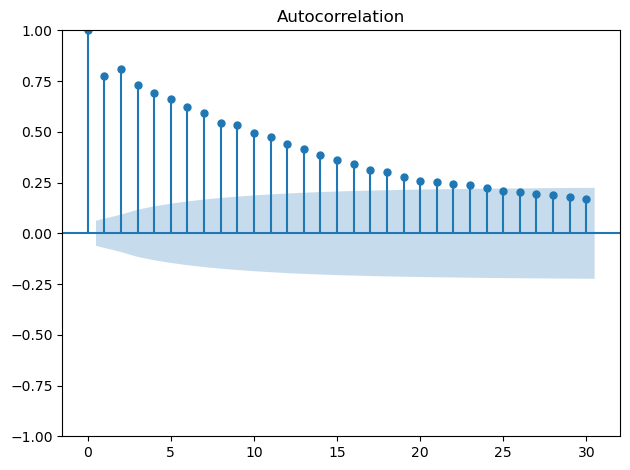

In [8]:
# ACF 시각화
# 자기상관관계가 있는지, 특정 지연 후에 계수가 갑자기 유의하지 않게 되는지 확인
plot_acf(foot_traffic_diff, lags = 30)

plt.tight_layout()

plt.show()

- 지연 0 이후에 유의한 자기상관계수가 있으므로 확률보행이 아님

- 또한 계수가 갑자기 유의하지 않게 되는 어떤 지연값이 존재하지 않고 점차적으로 감소함
    - 이동평균 프로세스가 없고 자기회귀 프로세스가 내재되어 있을 가능성이 높음
 
- AR(p) 프로세스의 차수 p를 식별할 수 있는 방법을 찾아야 함
    - 편자기상관함수(PACF)

## 편자기상관함수

- ACF 시각화로는 차수에 대한 정보를 얻을 수 없으므로 편자기상관함수(partial autocorrelation function, PACF)를 사용해야 함

- 자기상관관계는 시계열상 지연된 값들 간의 선형관계를 측정함
    - 즉, 자기상관함수는 지연이 증가함에 따라 두 값 사이의 상관관계가 어떻게 변하는지를 측정함
 
- 예) $y_t = 0.33y_{t-1} + 0.5y_{t-2}$ 의 AR(2) 프로세스가 있다고 가정
    - yt가 yt-2와 어떻게 관련되는지 상관관계를 측정한다면 이 작업은 ACF를 사용하여 수행
 
    - 하지만 수식을 보면 yt-1도 yt에 영향을 미침
 
    - 또한 AR(2) 프로세스에서 각 값은 이전의 두 번의 timestep값에 의존하기 때문에 yt-1 역시 yt-2의 영향을 받음
 
    - 따라서 ACF를 사용하여 yt와 yt-2 사이의 자기상관관계만 측정한다면 yt-1이 yt와 yt-2 둘 다 와 관계가 있다는 점을 고려하지 않은 것이 됨
 
    - 이를 해결하기 위해서 yt-1의 영향을 제거해야 함
        - ==yt와 yt-2 사이의 편자기상관관계를 측정해야 함
     
- 편자기상관관계는 시계열 내에서 지연된 값들 간의 상관관계를 측정할 수 있기 때문에 상관관계가 있는 지연된 값들 간의 영향도를 제거할 때 사용하거나 제거 결과를 확인할 때 사용
    - 이러한 상관관계가 있는 값들은 교란 변수(confounding variable)라고 부름

### AR(2) 프로세스 시뮬레이션

In [9]:
np.random.seed(42)

ma2 = np.array([1, 0, 0])
ar2 = np.array([1, -0.33, -0.5]) # AR 프로세스 계수들은 시뮬레이션 하려는 계수와 반대 부호로 지정해야 함

AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample = 1000)

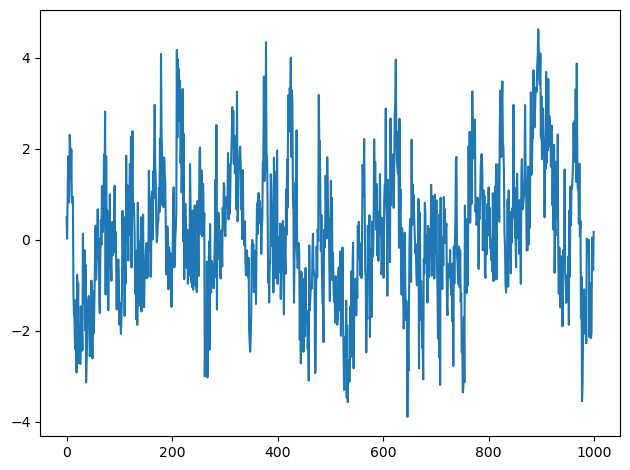

In [10]:
fig, ax = plt.subplots()

ax.plot(AR2_process)

plt.tight_layout()

plt.show()

In [11]:
ADF_result = adfuller(AR2_process)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -7.566606021416927
p-value: 2.914516129375917e-11


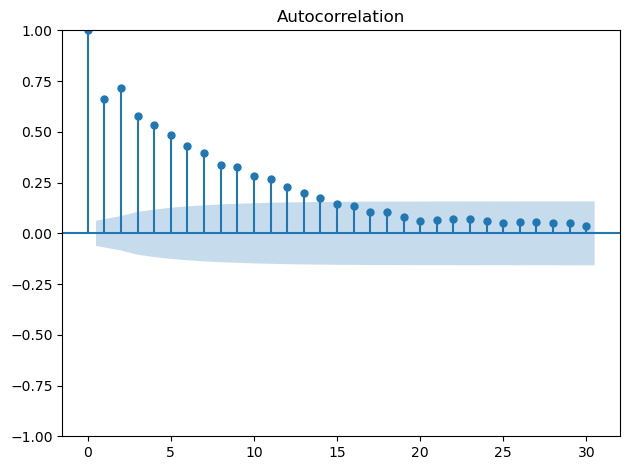

In [12]:
plot_acf(AR2_process, lags = 30)

plt.tight_layout()

plt.show()

- 시뮬레이션된 프로세스로 PACF 시각화
    - AR(2) 프로세스 이므로 지연 2 이후에 계수들이 유의하지 않게 되어야 함

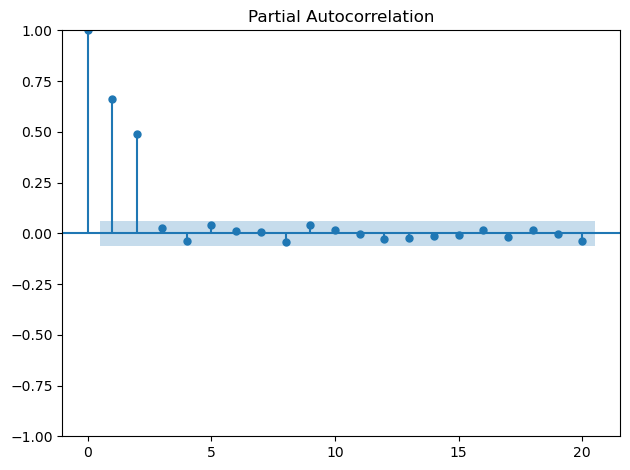

In [13]:
plot_pacf(AR2_process, lags = 20)

plt.tight_layout()

plt.show()

- 시뮬레이션된 프로세스는 차수가 2인 자기회귀 프로세스를 기반으로 하고 있음

### 소매점 주당 평균 유동인구에 적용

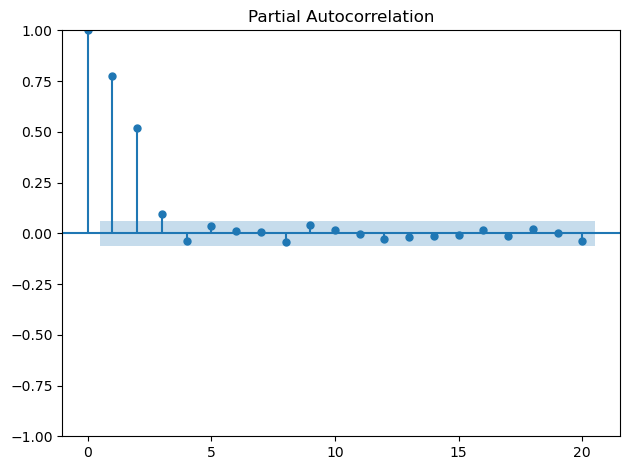

In [14]:
plot_pacf(foot_traffic_diff, lags = 20)

plt.tight_layout()

plt.show()

- 지연 3이후에는 유의한 계수가 없음
    - 따라서 차분된 주간 평균 유동 인구는 차수 3의 자기회귀 프로세스이며, AR(3)으로 표현할 수 있음

# 자기회귀 프로세스 예측

- 차수를 결정하고 나면 자기회귀 모델을 훈련하여 시계열을 예측할 수 있음
    - 이를 AR(p) 모델이라고 하며 p는 프로세스의 차수

In [15]:
df_diff = pd.DataFrame({"foot_traffic_diff" : foot_traffic_diff})

In [16]:
df_diff.shape

(999, 1)

In [17]:
train = df_diff[:-52]
test = df_diff[-52:]

print(len(train))
print(len(test))

947
52


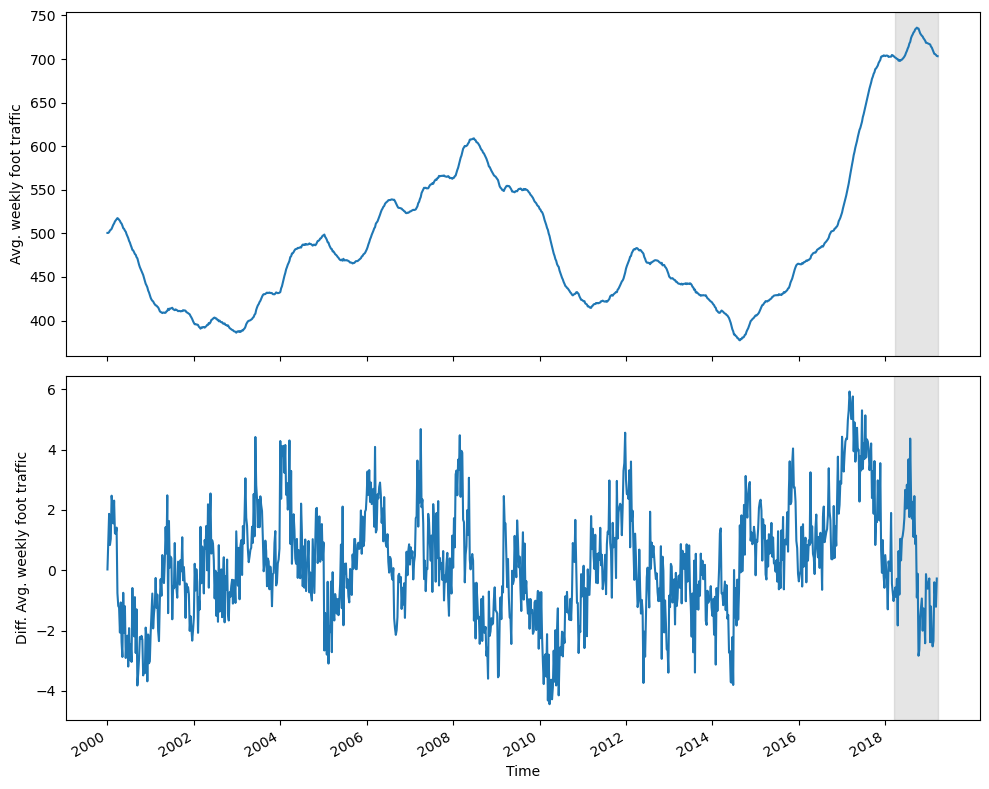

In [18]:
# 테스트 기간에 대해 원본 수열과 차분된 수열 모두 시각화
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, figsize = (10, 8))

ax1.plot(df["foot_traffic"])
ax1.set_xlabel("Time")
ax1.set_ylabel("Avg. weekly foot traffic")
ax1.axvspan(948, 1000, color = "#808080", alpha = 0.2)

ax2.plot(df_diff["foot_traffic_diff"])
ax2.set_xlabel("Time")
ax2.set_ylabel("Diff. Avg. weekly foot traffic")
ax2.axvspan(947, 999, color = "#808080", alpha = 0.2)

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 소매점의 다음 주 평균 유동인구를 예측하는 것이 목적이므로 테스트 집합에 대해 롤링 예측을 수행

- 데이터가 주 단위로 기록되었으므로 다음 timestep을 예측하는 것이 다음 주의 평균 유동인구를 예측한다는 뜻

- 세 가지 기법을 사용하여 예측
    - 베이스라인
        - 과거 평균
        - 마지막으로 측정된 값
    - AR(3) 모델

- 평균제곱오차를 사용하여 각 예측 기법의 성능을 평가

In [19]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str, p: int) -> list:
    '''
    df : 전체 시계열 데이터
    train_len : 훈련 집합의 크기
    horizon : 테스트 집합의 크기. 예측할 값의 개수
    window : 한 번에 예측할 timestep 개수
    method : 사용할 모델 지정
    p : AR 프로세스의 차수
    '''
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend([mean] * window)

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend([last_value] * window)

        return pred_last_value

    elif method == "AR":
        pred_AR = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order = (p, 0, 0))
            res = model.fit(disp = False) # disp : 훈련 과정을 화면에 출력할지 여부
            predictions = res.get_prediction(0, i + window - 1) # start, end
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)

        return pred_AR

In [20]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1
P = 3

In [21]:
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "mean", P)
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "last", P)
pred_AR = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "AR", P)

In [22]:
test["pred_mean"] = pred_mean
test["pred_last_value"] = pred_last_value
test["pred_AR"] = pred_AR

test.head()

,foot_traffic_diff,pred_mean,pred_last_value,pred_AR
947,-0.776601,0.213270,-1.021893,-0.719714
948,-0.574631,0.212226,-0.776601,-0.814547
949,-0.890697,0.211397,-0.574631,-0.664738
950,-0.283552,0.210237,-0.890697,-0.641469
951,-1.830685,0.209717,-0.283552,-0.579279


- 차분된 수열로 훈련하고 예측했으므로 예측 결과값도 차분된 값

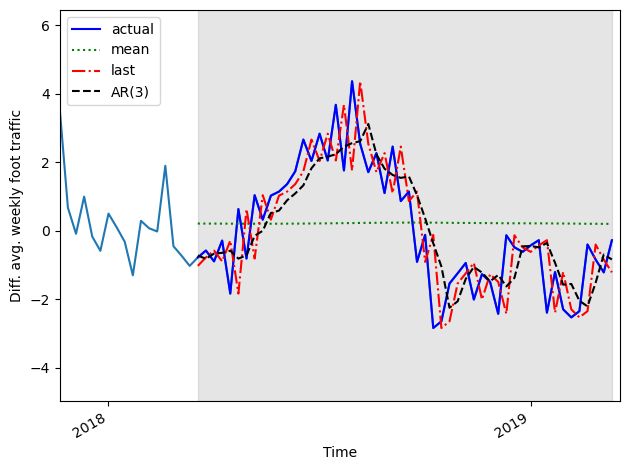

In [23]:
fig, ax = plt.subplots()

ax.plot(df_diff["foot_traffic_diff"])
ax.plot(test["foot_traffic_diff"], "b-", label = "actual")
ax.plot(test["pred_mean"], "g:", label = "mean")
ax.plot(test["pred_last_value"], "r-.", label = "last")
ax.plot(test["pred_AR"], "k--", label = "AR(3)")

ax.legend()

ax.set_xlabel("Time")
ax.set_ylabel("Diff. avg. weekly foot traffic")

ax.axvspan(947, 998, color = "#808080", alpha = 0.2)

plt.xticks([936, 988], [2018, 2019])

ax.set_xlim(930, 999)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [25]:
# MSE 평가
mse_mean = mean_squared_error(test["foot_traffic_diff"], test["pred_mean"])
mse_last = mean_squared_error(test["foot_traffic_diff"], test["pred_last_value"])
mse_AR = mean_squared_error(test["foot_traffic_diff"], test["pred_AR"])

print(mse_mean, mse_last, mse_AR)

3.1079979374701447 1.448730118495964 0.924247916471046


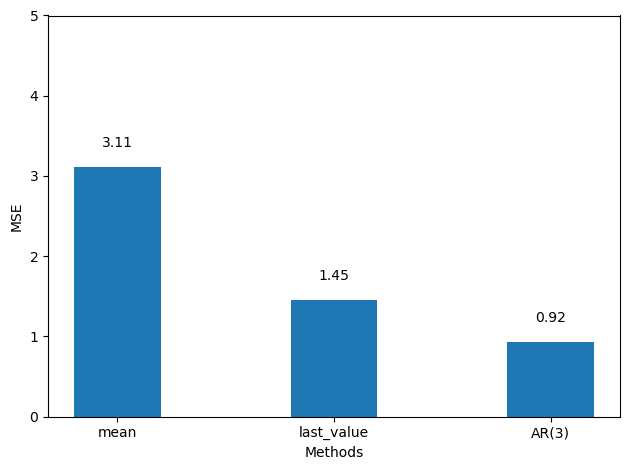

In [26]:
fig, ax = plt.subplots()

x = ["mean", "last_value", "AR(3)"]
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width = 0.4)
ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

- AR(3) 모델의 MSE가 세 가지 기법 중 가장 낮으므로 AR(3) 모델이 다음 주 평균 유동인구를 예측하는 데 가장 적합한 기법임

- 예측값은 차분된 값이므로 예측값을 원래의 단위로 되돌리려면 변환을 해야함
    - 예측의 누적 합계를 원본 수열의 훈련 집합 중 마지막 값에 더하기
    - 1000개의 데이터 집합에서 지난 52주를 테스트 데이터로 사용했으므로 예측값의 시작 지점은 인덱스 948

In [27]:
df["pred_foot_traffic"] = pd.Series()
df["pred_foot_traffic"][948:] = df["foot_traffic"].iloc[948] + test["pred_AR"].cumsum()

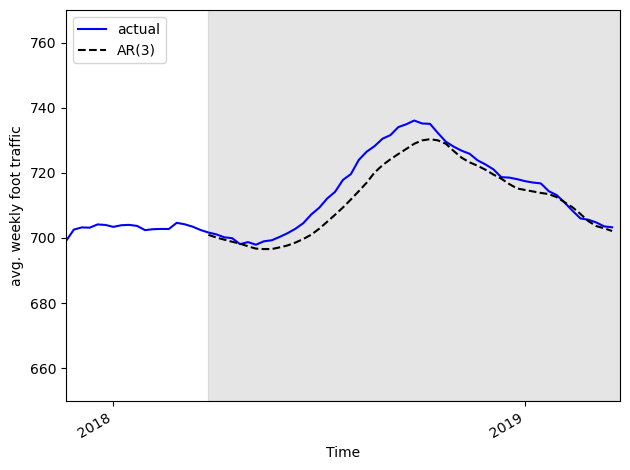

In [29]:
# 차분하지 않은 예측값을 원본 수열의 관측값과 비교 시각화
fig, ax = plt.subplots()

ax.plot(df["foot_traffic"], "b-", label = "actual")
ax.plot(df["pred_foot_traffic"], "k--", label = "AR(3)")

ax.legend()

ax.set_xlabel("Time")
ax.set_ylabel("avg. weekly foot traffic")

ax.axvspan(948, 1000, color = "#808080", alpha = 0.2)

plt.xticks([936, 988], [2018, 2019])

ax.set_xlim(930, 1000)
ax.set_ylim(650, 770)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 모델의 예측값이 테스트 집합 내 관측값의 일반적인 추세를 따르고 있음

In [30]:
mae_AR_undiff = mean_absolute_error(df["foot_traffic"][948:], df["pred_foot_traffic"][948:])

print(mae_AR_undiff)

3.478033557251098


# 연습문제

## 예측 수행하기_1

1. 데이터 시각화
2. 정상성 테스트
3. 정상성 만족하지 않는 경우 차분
4. ACF 시각화
5. 필요시 PACF 시각화
6. 수열을 훈련/테스트 분할(8:2)
7. 테스트 집합에 대한 예측 수행
8. 예측값 시각화
9. MSE 측정
10. MSE 시각화

In [32]:
process = np.load("./data/q5-1.npy")

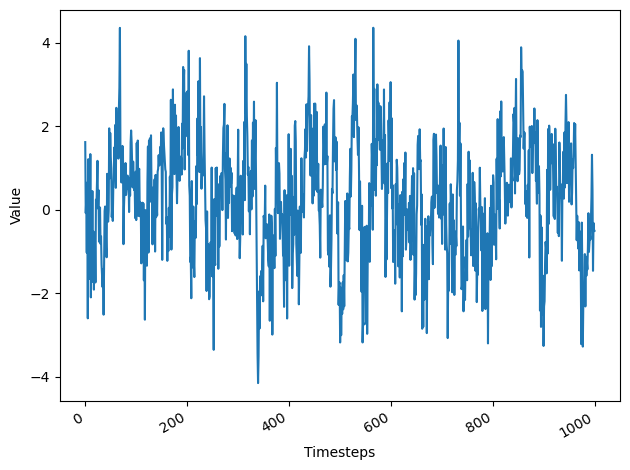

In [33]:
# 프로세스 시각화
fig, ax = plt.subplots()

ax.plot(process)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [34]:
# 정상성 테스트
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -8.147187308838815
p-value: 9.916148570628805e-13


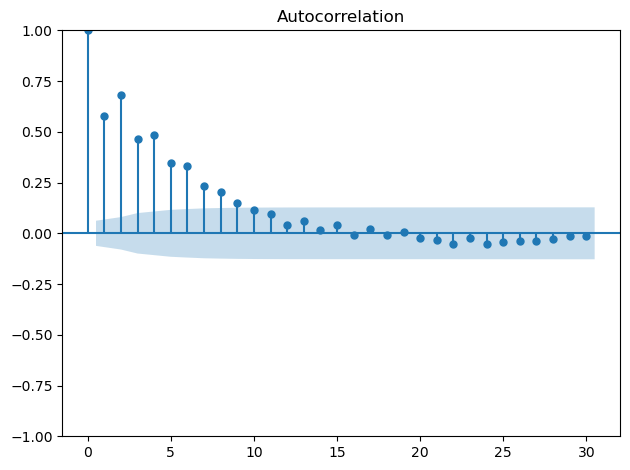

In [35]:
plot_acf(process, lags = 30)
plt.tight_layout()
plt.show()

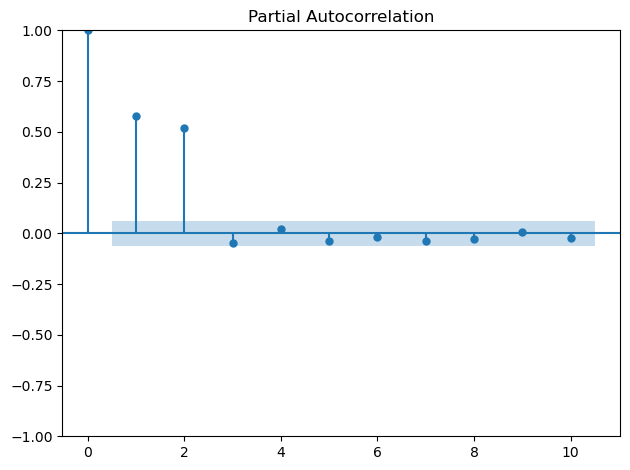

In [36]:
plot_pacf(process, lags = 10)

plt.tight_layout()
plt.show()

In [37]:
df = pd.DataFrame({"value" : process})

df.shape

(1000, 1)

In [38]:
train = df[:800]
test = df[800:]

In [39]:
P = 2
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

In [40]:
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "mean", P)
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "last", P)
pred_AR = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "AR", P)

In [41]:
test["pred_mean"] = pred_mean
test["pred_last_value"] = pred_last_value
test["pred_AR"] = pred_AR

test.head()

,value,pred_mean,pred_last_value,pred_AR
800,0.830677,0.177760,-0.812289,0.086300
801,0.648449,0.177760,-0.812289,-0.406891
802,-0.834727,0.179161,0.648449,0.610615
803,-0.105727,0.179161,0.648449,0.504270
804,-0.544686,0.177545,-0.105727,-0.468564


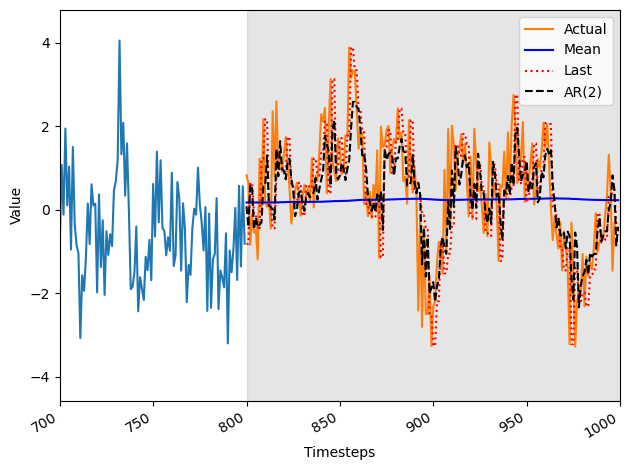

In [44]:
# 예측값 시각화
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test["value"], label = "Actual")
ax.plot(test["pred_mean"], "b-", label = "Mean")
ax.plot(test["pred_last_value"], "r:", label = "Last")
ax.plot(test["pred_AR"], "k--", label = "AR(2)")

ax.legend()

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

ax.axvspan(800, 1000, color = "#808080", alpha = 0.2)

ax.set_xlim(700, 1000)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [45]:
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_AR = mean_squared_error(test["value"], test["pred_AR"])

print(mse_mean, mse_last, mse_AR)

1.8853022529824557 1.3739861321119122 0.9022271562865178


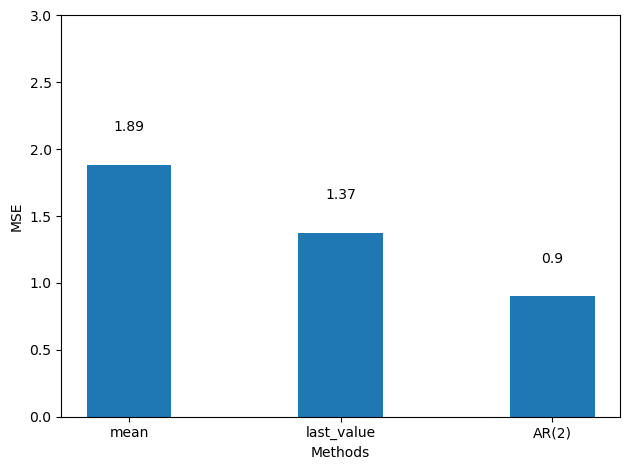

In [46]:
fig, ax = plt.subplots()

x = ["mean", "last_value", "AR(2)"]
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width = 0.4)
ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 3)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

## 예측수행하기_2

In [47]:
process = np.load("./data/q5-2.npy")

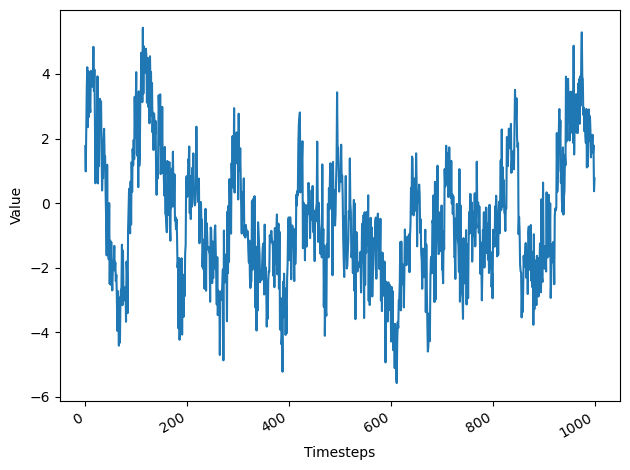

In [48]:
# 프로세스 시각화
fig, ax = plt.subplots()

ax.plot(process)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [49]:
# 정상성 테스트
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -4.153359039752754
p-value: 0.0007894799577558016


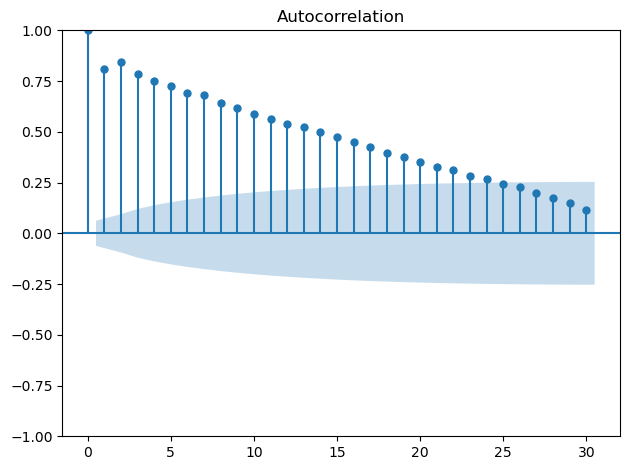

In [50]:
plot_acf(process, lags = 30)

plt.tight_layout()
plt.show()

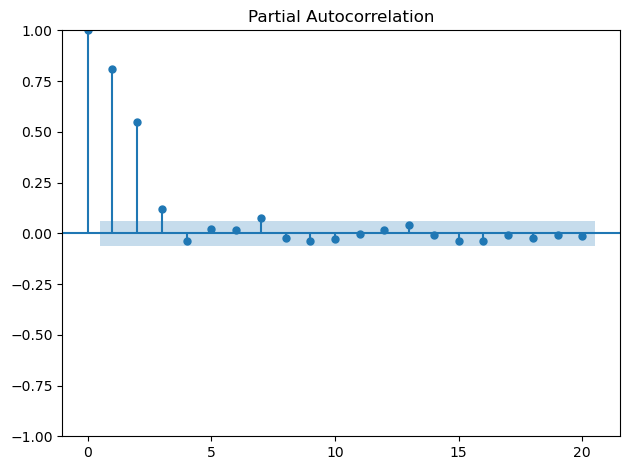

In [51]:
plot_pacf(process, lags = 20)

plt.tight_layout()
plt.show()

In [52]:
df = pd.DataFrame({"value" : process})

train = df[:-200]
test = df[-200:]

In [53]:
df.shape

(1000, 1)

In [54]:
train.shape

(800, 1)

In [55]:
test.shape

(200, 1)

In [56]:
P = 3
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

In [57]:
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "mean", P)
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "last", P)
pred_AR = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "AR", P)

In [58]:
test["pred_mean"] = pred_mean
test["pred_last_value"] = pred_last_value
test["pred_AR"] = pred_AR

test.head()

,value,pred_mean,pred_last_value,pred_AR
800,-0.826726,-0.684431,-2.949518,-2.292511
801,-1.113366,-0.684431,-2.949518,-2.448781
802,-1.044710,-0.685143,-1.113366,-1.087856
803,-1.350525,-0.685143,-1.113366,-0.990728
804,-0.105046,-0.686418,-1.350525,-1.066794


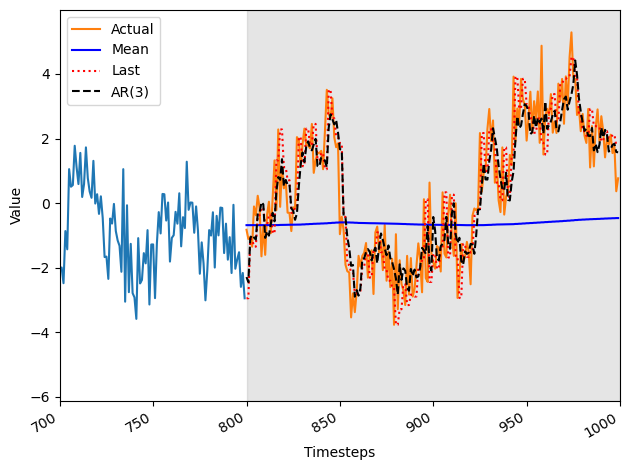

In [59]:
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test["value"], label = "Actual")
ax.plot(test["pred_mean"], "b-", label = "Mean")
ax.plot(test["pred_last_value"], "r:", label = "Last")
ax.plot(test["pred_AR"], "k--", label = "AR(3)")

ax.legend()

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

ax.axvspan(800, 1000, color = "#808080", alpha = 0.2)

ax.set_xlim(700, 1000)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [60]:
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_AR = mean_squared_error(test["value"], test["pred_AR"])

print(mse_mean, mse_last, mse_AR)

5.294771816584867 1.2175700179409947 0.9051739150091166


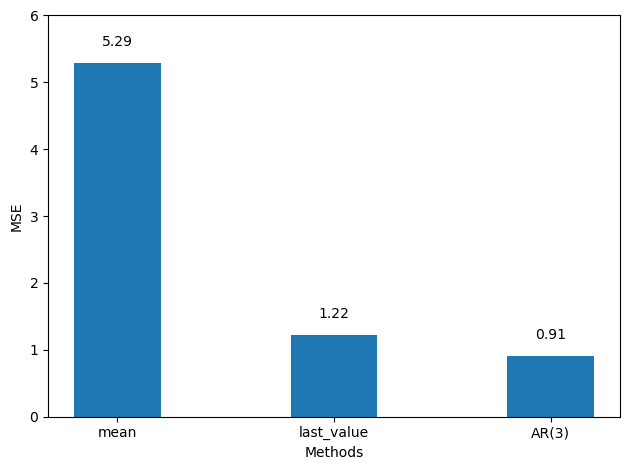

In [61]:
fig, ax = plt.subplots()

x = ["mean", "last_value", "AR(3)"]
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width = 0.4)
ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 6)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

# 정리

- 자기회귀 모델은 현재 값이 과거의 값들과 현재 발생한 오차의 선형결합으로 결정된다고 보는 모델

- 정상적 프로세스의 ACF그래프에 느린 감쇄가 보이면 자기회귀 프로세스가 있을 가능성이 높음

- 정상적 자기회귀프로세스의 PACF를 시각화하면 프로세스의 차수 p를 확인할 수 있음
    - 계수는 지연 p까지만 유의함